# Финальный проект по продуктовой аналитике

## Введение

Вы — аналитик данных в стартапе, который развивает новый маркетплейс с товарами из Бразилии, недавно вышедшими на рынок.

Продакт-менеджер Петя обеспокоен: выручка маркетплейса не растет уже несколько месяцев. Он дает полную свободу действий с двумя ключевыми условиями:

- метрики должны расти;
- решения не должны ухудшать пользовательский опыт.


## Задачи проекта

1. Оценить месячный retention в оформление заказа с помощью когортного анализа.
2. Определить, существует ли у маркетплейса product/market fit.
3. Определить 5 ключевых метрик, на которых продакту стоит сфокусироваться для максимизации прибыли компании.
4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.
5. Определить метрики, на которые должна повлиять выбранная гипотеза.
6. Сформулировать выводы по проделанной работе и подготовить итоговый отчет.


## Датасет

### 1) `olist_customers_dataset.csv`
Таблица с идентификаторами пользователей.

- `customer_id` — позаказный идентификатор пользователя.
- `customer_unique_id` — уникальный идентификатор пользователя (аналог номера паспорта).
- `customer_zip_code_prefix` — почтовый индекс пользователя.
- `customer_city` — город доставки пользователя.
- `customer_state` — штат доставки пользователя.

### 2) `olist_orders_dataset.csv`
Таблица заказов.

- `order_id` — уникальный идентификатор заказа (номер чека).
- `customer_id` — позаказный идентификатор пользователя.
- `order_status` — статус заказа.
- `order_purchase_timestamp` — время создания заказа.
- `order_approved_at` — время подтверждения оплаты заказа.
- `order_delivered_carrier_date` — время передачи заказа в логистическую службу.
- `order_delivered_customer_date` — время доставки заказа.
- `order_estimated_delivery_date` — обещанная дата доставки.

### 3) `olist_order_items_dataset.csv`
Товарные позиции в заказах.

- `order_id` — уникальный идентификатор заказа (номер чека).
- `order_item_id` — идентификатор товара внутри заказа.
- `product_id` — ID товара (аналог штрихкода).
- `seller_id` — ID производителя товара.
- `shipping_limit_date` — крайняя дата передачи заказа в логистику со стороны продавца.
- `price` — цена за единицу товара.
- `freight_value` — вес товара.

Пример структуры данных можно визуализировать на `order_id == 00143d0f86d6fbd9f9b38ab440ac16f5`.

### Статусы заказов (`olist_orders_dataset`)

- `created` — создан;
- `approved` — подтвержден;
- `invoiced` — выставлен счет;
- `processing` — в процессе сборки заказа;
- `shipped` — отгружен со склада;
- `delivered` — доставлен пользователю;
- `unavailable` — отменен по причине недоступности товара;
- `canceled` — отменен.


### Впорос по колонке `freight_value` для проверяющего

В описании датасета указано, что `freight_value` - это **вес товара**.

При этом в логистике freight обычно означает фрахт/перевозку груза - возможно, это стоимость доставки?

Проверила в интернете:
На открытых материалах по датасету **Olist** (Brazilian E-Commerce Public Dataset by Olist) на платформе **Kaggle** (публичная платформа для публикации датасетов и соревнований по анализу данных) обычно описывают `freight_value` как **стоимость доставки**, распределённую по строкам позиций заказа, а не как вес.

Я не буду использвоать эту колонку в работе, но если это стоимость доставки, ее можно ключать в метрики, так как стоимость доставки - важный параметр для маркетплейса, ее нужно учитывать в выручке.

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
from operator import attrgetter
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
from statsmodels.stats.proportion import proportions_ztest

In [22]:
#функция для описания датасета
def df_overview (df):
    print("\nПервые 5 строк:")
    display(df.head())

    print("\nИнформация о датасете (df.info()):")
    df.info()

    missing_cols = df.columns[df.isna().any()].tolist()
    print("\nПеременные с пропусками:")
    if missing_cols:
        for col in missing_cols:
            n_miss = df[col].isna().sum()
            p_miss = df[col].isna().mean() * 100
            print(f"- {col}: {n_miss} ({p_miss:.2f}%)")
    else:
        print("Пропусков нет")

In [23]:
customers = pd.read_csv('olist_customers_dataset.csv', sep = ',')
df_overview(customers)


Первые 5 строк:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Информация о датасете (df.info()):
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB

Переменные с пропусками:
Пропусков нет


In [47]:
oi_date_cols = ["shipping_limit_date"]
order_items = pd.read_csv('olist_order_items_dataset.csv', sep = ',', parse_dates = oi_date_cols)
df_overview(order_items)


Первые 5 строк:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



Информация о датасете (df.info()):
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 16.3 MB

Переменные с пропусками:
Пропусков нет


In [25]:
orders_date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
orders = pd.read_csv('olist_orders_dataset.csv', parse_dates = orders_date_cols)
df_overview(orders)


Первые 5 строк:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26



Информация о датасете (df.info()):
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 13.0 MB

Переменные с пропусками:
- order_approved_at: 160 (0.16%)
- order_delivered_carrier_date: 1783 (1.79%)
- order_delivered_customer_date: 2965

In [26]:
# Данные для визуализации динамики заказов
# общий тренд заказов — число уникальных order_id в каждом месяце
orders_by_month = (
    orders
    .assign(order_month=orders["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp())
    .groupby("order_month", as_index=False)
    .agg(orders_cnt=("order_id", "nunique"))
)

# статусы заказов по месяцам - counts
status_by_month = (
    orders
    .assign(order_month=orders["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp())
    .groupby(["order_month", "order_status"], as_index=False)
    .agg(orders_cnt=("order_id", "nunique"))
)

# статусы заказов по месяцам - доли
status_share_by_month = status_by_month.copy()
status_share_by_month["share"] = (
    status_share_by_month["orders_cnt"]
    / status_share_by_month.groupby("order_month")["orders_cnt"].transform("sum")
)

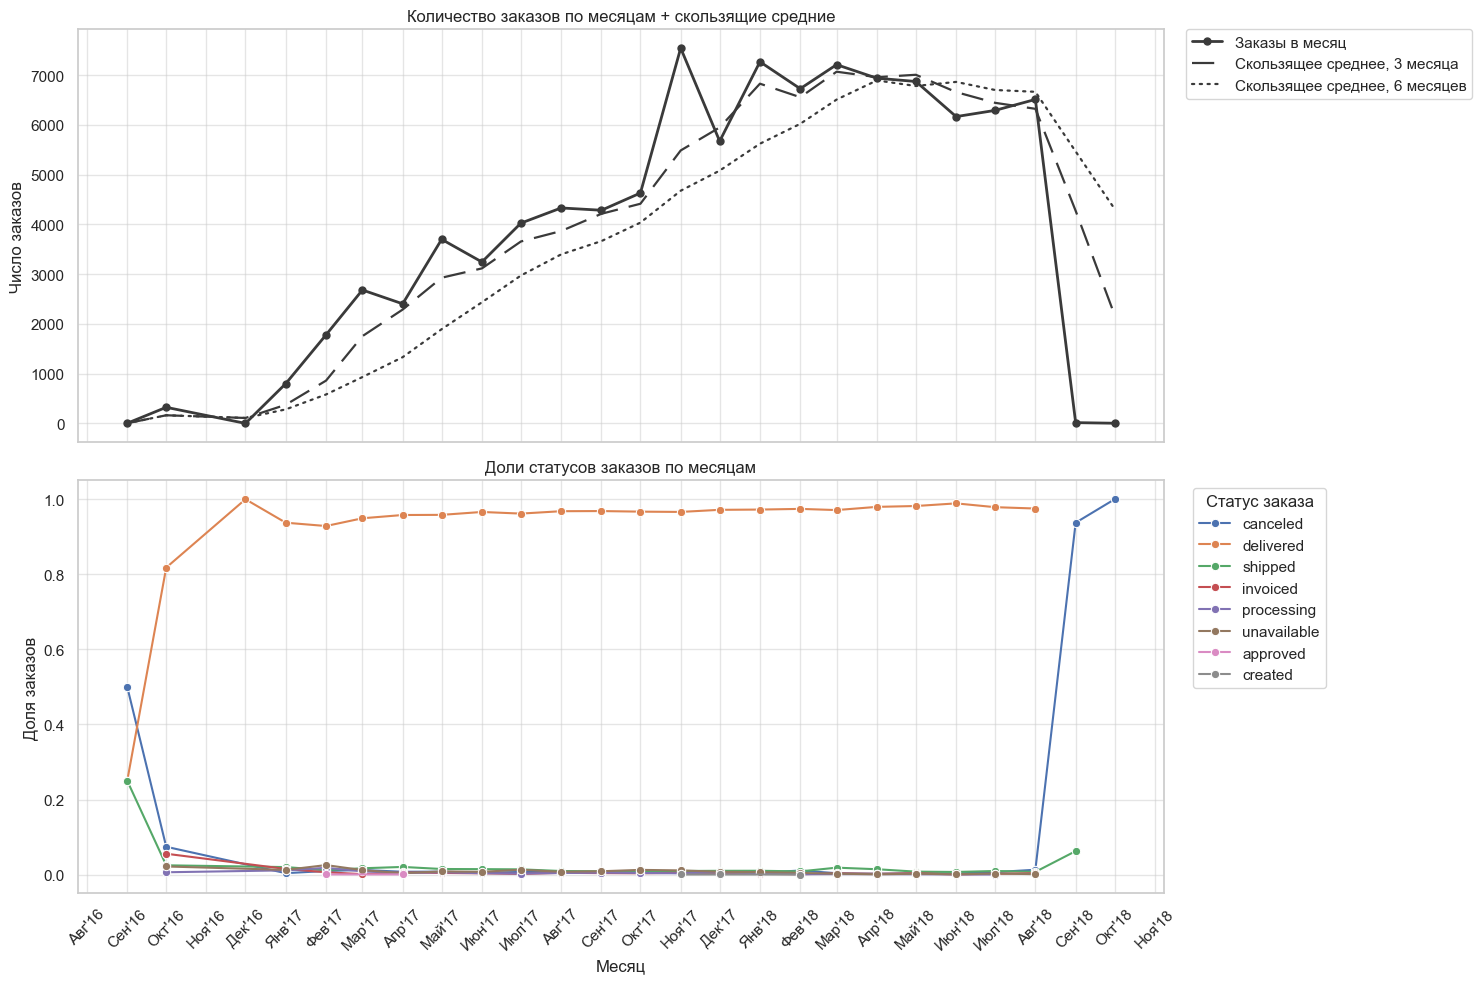

In [27]:
#График: динамика заказов по месяцам
LINE_COLOR = "#3A3A3A"  # мягкий тёмно-серый, не «чернильный» чёрный

orders_ts = orders_by_month.sort_values("order_month").reset_index(drop=True)
orders_ts["ma_3m"] = orders_ts["orders_cnt"].rolling(window=3, min_periods=1).mean()
orders_ts["ma_6m"] = orders_ts["orders_cnt"].rolling(window=6, min_periods=1).mean()

RU_MONTH_SHORT = {
    1: "янв", 2: "фев", 3: "мар", 4: "апр", 5: "май", 6: "июн",
    7: "июл", 8: "авг", 9: "сен", 10: "окт", 11: "ноя", 12: "дек",
}


def format_ru_month_year(x, pos=None):
    dt = mdates.num2date(x).replace(tzinfo=None)
    mon = RU_MONTH_SHORT[dt.month].capitalize()
    return f"{mon}'{dt.year % 100:02d}"


sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

x = orders_ts["order_month"]

# Заказы в месяц — сплошная, чуть толще
axes[0].plot(
    x,
    orders_ts["orders_cnt"],
    color=LINE_COLOR,
    linestyle="-",
    linewidth=2.0,
    marker="o",
    markersize=5,
    label="Заказы в месяц",
    zorder=3,
)

# 3 мес. — длинные штрихи, без маркеров
axes[0].plot(
    x,
    orders_ts["ma_3m"],
    color=LINE_COLOR,
    linestyle=(0, (10, 5)),
    linewidth=1.6,
    label="Скользящее среднее, 3 месяца",
    zorder=2,
)

# 6 мес. — «точки» по линии
axes[0].plot(
    x,
    orders_ts["ma_6m"],
    color=LINE_COLOR,
    linestyle=(0, (1, 2.5)),
    linewidth=1.6,
    dash_capstyle="round",
    label="Скользящее среднее, 6 месяцев",
    zorder=1,
)

axes[0].set_title("Количество заказов по месяцам + скользящие средние")
axes[0].set_ylabel("Число заказов")
axes[0].set_xlabel("")
axes[0].legend(bbox_to_anchor=(1.02, 1.0), loc="upper left", borderaxespad=0.0)

sns.lineplot(
    data=status_share_by_month,
    x="order_month",
    y="share",
    hue="order_status",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Доли статусов заказов по месяцам")
axes[1].set_ylabel("Доля заказов")
axes[1].set_xlabel("Месяц")
axes[1].legend(title="Статус заказа", bbox_to_anchor=(1.02, 1), loc="upper left")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_ru_month_year))
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Первичная визуализация проблемы: динамика заказов

На первом этапе я посмотрела динамику по месяцам за всю историю наблюдений: общее число заказов и доли статусов.

**Историю работы маркетплейса можно разделить на несколько периодов:**

1. **Запуск (сентябрь — декабрь 2016).**
   - Сентябрь 2016 — первые заказы, в том числе доставленные, отправленные и отменённые.
   - Октябрь 2016 — небольшой рост числа заказов.
   - Ноябрь 2016 — в данных нет заказов за месяц (нулевой объём).
   - Декабрь 2016 — нет новых заказов, видны только доставки ранее оформленных.

   Если выгрузка полная и ошибок логирования не было, это похоже на пробный запуск в сентябре–октябре и паузу в ноябре–декабре. Альтернатива — технический или операционный разрыв в данных, который стоит проверить отдельно.

2. **Нормальная работа (январь 2017 — январь 2018).**

   В 2017 году среднее число заказов в целом растёт, при выраженном тренде на рост наблюдаются сезонные колебания:
   - рост в **ноябре 2017** — вероятный сезонный фактор (предновогодний спрос, распродажи вроде «Чёрной пятницы»);
   - небольшое снижение в **декабре 2017** и снова высокий уровень в **январе 2018** — разумнее трактовать как **возврат к обычным значениям после ноябрьского пика**, а не как падение спроса.

3. **Остановка роста и снижение (февраль — август 2018).**
   Зима и весна 2018 (февраль–май): число заказов почти не растёт и держится около **6 тыс.** в месяц.
   Лето 2018: есть локальные колебания, но суммарный объём заказов заметно ниже весеннего уровня.

4. **Резкий обвал (осень 2018).**
   В **сентябре 2018** поток заказов почти нулевой: доставленных почти нет, растёт доля **отменённых**, в сентябре виден хвост **отправленных**.
   В **октябре 2018** в данных фактически только отмены — без новых заказов и отправок. Это может означать остановку работы маркетплейса, смену процесса или особенность выгрузки; нужно сверить с датой среза данных и бизнес-контекстом.

В «нормальный» период доминирует доля **доставленных**; остальные статусы каждый месяц присутствуют, но с малыми долями. На графиках виден длительный участок с преобладанием доставок и резкий перелом **осенью 2018**: почти нет новых заказов, в статусах — в основном отмены. Это может указывать на кризис операционной модели или на сбой/обрыв логирования в данных.

### Задача 1. Оценить месячный retention в оформление заказа с помощью когортного анализа.

На первом этапе вы решили посмотреть на метрики маркетплейса и на возвращаемость клиента в продукт.

Для этого вам нужно:

Оценить месячный retention в оформление заказа с помощью когортного анализа, так как важно, чтобы клиенты возвращались в маркетплейс для совершения больших покупок.

В рамках исследования необходимо:

- Исследовать датасет и определить, какой вид заказа будет учитываться в retention
- Построить месячный retention
- Проанализировать, чему равен медианный retention 1-го месяца (т.е. взять retention 1-ого месяца для всех когорт и посчитать по этим числам медиану)
- Найти когорту с самым высоким retention на 3-й месяц.
- Проиллюстрировать результаты релевантной визуализацией, удобной для восприятия.

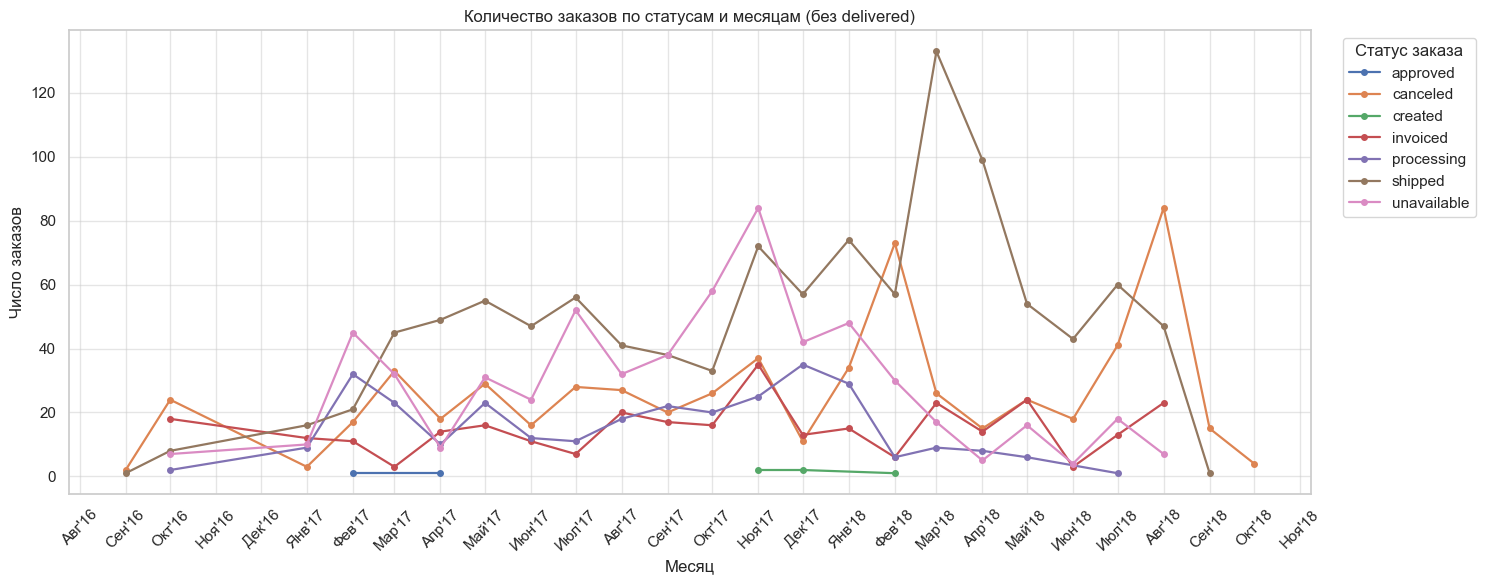

In [28]:
#Проверка статусов заказов без delivered
status_no_delivered = status_by_month[status_by_month["order_status"] != "delivered"].copy()

fig, ax = plt.subplots(figsize=(15, 6))

for status, grp in status_no_delivered.groupby("order_status"):
    grp = grp.sort_values("order_month")
    ax.plot(grp["order_month"], grp["orders_cnt"], marker="o", markersize=4, linewidth=1.6, label=status)

ax.set_title("Количество заказов по статусам и месяцам (без delivered)")
ax.set_ylabel("Число заказов")
ax.set_xlabel("Месяц")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_ru_month_year))
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Статус заказа", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [29]:
status_pivot = status_by_month.pivot_table(
    index='order_month',
    columns='order_status',
    values='orders_cnt',
    fill_value=0
).sort_index()

status_pivot

order_status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable
order_month,,,,,,,,
2016-09-01,0.0,2.0,0.0,1.0,0.0,0.0,1.0,0.0
2016-10-01,0.0,24.0,0.0,265.0,18.0,2.0,8.0,7.0
2016-12-01,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2017-01-01,0.0,3.0,0.0,750.0,12.0,9.0,16.0,10.0
2017-02-01,1.0,17.0,0.0,1653.0,11.0,32.0,21.0,45.0
2017-03-01,0.0,33.0,0.0,2546.0,3.0,23.0,45.0,32.0
2017-04-01,1.0,18.0,0.0,2303.0,14.0,10.0,49.0,9.0
2017-05-01,0.0,29.0,0.0,3546.0,16.0,23.0,55.0,31.0
2017-06-01,0.0,16.0,0.0,3135.0,11.0,12.0,47.0,24.0


### Выбор статуса заказов для Retention-анализа

Жизненный цикл заказа завершается стасусом `delivered`, им обладают 97% всех заказов в базе (96 478 из 99 441).
Остальные 3% приходятся на незавершенные заказы:

| Статус заказа             | Кол-во | Доля | Комментарий                           |
|---------------------------|--------|------|---------------------------------------|
| `delivered`               | 96 478 | 97.02% | ✅ Включаем в анализ                   |
| `shipped`                 | 1 107 | 1.11% | Заказ в пути, транзакция не завершена |
| `canceled`                | 625 | 0.63% | Отменённые — не покупка               |
| `unavailable`             | 609 | 0.61% | Товар недоступен                      |
| `invoiced` / `processing` | 615 | 0.62% | Промежуточные статусы                 |
| `created` / `approved`    | 7 | <0.01% | Единичные случаи                      |

Статусы `canceled`,`unavailable`, `invoiced` и `processing` — незавершённые покупки, которые не отражают реальное потребительское поведение.
Включать статус `shipped` в анализ нецелесообразно - добавление этого статуса даст незначительный прирост к выборке (+1.1%), при этом данные будет сложнее интерпретировать, так как статус не финальный: заказ может быть возвращён или отменён.


**Вывод:** В качестве целевого события для retention-анализа выбран статус `delivered`.
Он отражаюет завершённую транзакцию: факт покупки состоялся, товар доставлен клиенту. На него приходится 97% всех заказов; включение остальных статусов дало бы незначительный прирост выборки и исказило бы интерпретацию, так как они описывают незавершённые или неуспешные покупки.
**Ограничение интерпретации:** выбранная метрика отражает возвращаемость клиентов к *успешно доставленному* заказу, а не к факту оформления покупки на ранних этапах воронки. Клиенты, чьи заказы были отменены, зависли в `processing` или попали в `unavailable`, в анализе не участвуют — соответственно, retention не учитывает потери на пути от оформления до доставки.

Построить месячный retention

In [30]:
#подтянуть уникальный айди клиента
#фильтр на статус заказа delivered
# .copy() чтобы работать с отдельной копией, а не view исходного DataFrame
flt_orders = (
    orders.query("order_status =='delivered'")
    .merge(
        customers[['customer_id', 'customer_unique_id']],
        on='customer_id',
        how='left'
    )
    .copy()
)

flt_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6


In [31]:
# --- Данные по когортам ---

# Работа с копией, чтобы не менять исходный DataFrame
flt_orders = flt_orders.copy()

# Месяц покупки (период M) для каждой строки заказа
flt_orders['order_period'] = flt_orders['order_purchase_timestamp'].dt.to_period('M')

# Когорта пользователя = месяц его первой покупки
flt_orders['cohort'] = (
    flt_orders.groupby('customer_unique_id')['order_purchase_timestamp']
    .transform('min')
    .dt.to_period('M')
)

# Номер месяца жизни когорты: M0, M1, M2, ...
flt_orders['period_number_month'] = (
    flt_orders['order_period'] - flt_orders['cohort']
).apply(attrgetter('n'))

# Считаем число уникальных пользователей в каждой паре (когорта, период)
df_cohort = (
    flt_orders
    .groupby(['cohort', 'period_number_month'], as_index=False)
    .agg(n_customers=('customer_unique_id', 'nunique'))
)

# Переводим в формат широкой таблицы: строки — когорты, столбцы — периоды, значения — n клиентов
cohort_pivot = df_cohort.pivot_table(
    index='cohort',
    columns='period_number_month',
    values='n_customers'
)

In [32]:
# --- расчет retention, проверка на стат значимость различий, подготовка к визуализации ---

# Уровень значимости для z-теста долей
alpha = 0.05

# Размер когорты = число пользователей в нулевом периоде (M0)
cohort_size = cohort_pivot.loc[:, 0].astype(float)

# Исключаем слишком маленькие когорты (n <= 1), чтобы убрать шум
valid_cohorts = cohort_size[cohort_size > 1].index
cp = cohort_pivot.loc[valid_cohorts].copy()
cz = cohort_size.loc[valid_cohorts]

# Считаем retention: доля вернувшихся пользователей в каждом периоде
retention_matrix = cp.div(cz, axis=0)

# Для графика убираем M0 (всегда 100%) и оставляем только M1+
retention_for_plot = retention_matrix.iloc[:, 1:].copy()
counts_for_plot = cp.iloc[:, 1:].copy()

# Средний retention по каждому периоду (база для сравнения когорт)
period_mean = retention_for_plot.mean(axis=0)

# Отклонение retention когорты от среднего retention периода
deviation = retention_for_plot.subtract(period_mean, axis=1)

# Матрицы для p-value и статистически значимых отклонений
pvalue_matrix = pd.DataFrame(
    index=retention_for_plot.index,
    columns=retention_for_plot.columns,
    dtype=float,
)
significant_deviation = pd.DataFrame(
    index=retention_for_plot.index,
    columns=retention_for_plot.columns,
    dtype=float,
)

# Для каждой когорты и периода:
# сравниваем retention этой когорты с объединением всех остальных когорт (двусторонний z-тест долей)
for period in retention_for_plot.columns:
    period_counts = counts_for_plot[period]
    for cohort in retention_for_plot.index:
        count_1 = period_counts.loc[cohort]
        nobs_1 = cz.loc[cohort]

        # Если данных нет — сохраняем NaN
        if pd.isna(count_1) or pd.isna(nobs_1):
            pvalue_matrix.loc[cohort, period] = np.nan
            significant_deviation.loc[cohort, period] = np.nan
            continue

        # Группа сравнения = все остальные когорты с ненулевыми данными в периоде
        other_counts = period_counts.drop(index=cohort).dropna()
        if other_counts.empty:
            pvalue_matrix.loc[cohort, period] = np.nan
            significant_deviation.loc[cohort, period] = np.nan
            continue

        other_cohorts = other_counts.index
        count_2 = other_counts.sum()
        nobs_2 = cz.loc[other_cohorts].sum()

        # Защита от некорректных малых выборок
        if nobs_1 <= 1 or nobs_2 <= 1:
            pvalue_matrix.loc[cohort, period] = np.nan
            significant_deviation.loc[cohort, period] = np.nan
            continue

        # Двусторонний тест: отличается ли доля удержания от остальных когорт
        _, pval = proportions_ztest(
            count=[count_1, count_2],
            nobs=[nobs_1, nobs_2],
            alternative="two-sided",
        )

        pvalue_matrix.loc[cohort, period] = pval

        # Сохраняем отклонение только если отличие статистически значимо
        if pval < alpha:
            significant_deviation.loc[cohort, period] = deviation.loc[cohort, period]
        else:
            significant_deviation.loc[cohort, period] = np.nan

# краткие названия месяцев для подписей когорт
RU_MONTH_SHORT = {
    1: "янв", 2: "фев", 3: "мар", 4: "апр", 5: "май", 6: "июн",
    7: "июл", 8: "авг", 9: "сен", 10: "окт", 11: "ноя", 12: "дек",
}

# Форматируем индекс когорт в вид "Мар'17"
def cohort_index_to_ru(idx):
    out = []
    for x in idx:
        if isinstance(x, pd.Period):
            dt = x.to_timestamp()
        else:
            dt = pd.to_datetime(x)
        if getattr(dt, "tzinfo", None) is not None:
            dt = dt.tz_localize(None)
        mon = RU_MONTH_SHORT[dt.month].capitalize()
        out.append(f"{mon}'{dt.year % 100:02d}")
    return out

# Применяем подписи на русском ко всем связанным таблицам
_ru = cohort_index_to_ru(retention_for_plot.index)
retention_for_plot.index = _ru
counts_for_plot.index = _ru
cz.index = _ru
significant_deviation.index = _ru
pvalue_matrix.index = _ru

# Подписи для ячеек heatmap в процентах
annot_retention = retention_for_plot.map(
    lambda x: f"{100 * x:.2f}%" if pd.notna(x) else ""
)

# Приводим номера периодов к строкам: "1", "2", "3", ...
def period_cols_as_n(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    d.columns = [str(int(c)) for c in d.columns]
    return d

# Финальные таблицы для отображения
ret_disp = period_cols_as_n(retention_for_plot)
sig_disp = period_cols_as_n(significant_deviation)
annot_disp = period_cols_as_n(annot_retention)

# Масштаб цвета: сначала по значимым отклонениям,
# если их нет — по всем отклонениям, иначе минимальный дефолт
v = np.nanmax(np.abs(significant_deviation.values))
if np.isnan(v) or v == 0:
    v = np.nanmax(np.abs(deviation.values))
if np.isnan(v) or v == 0:
    v = 0.01

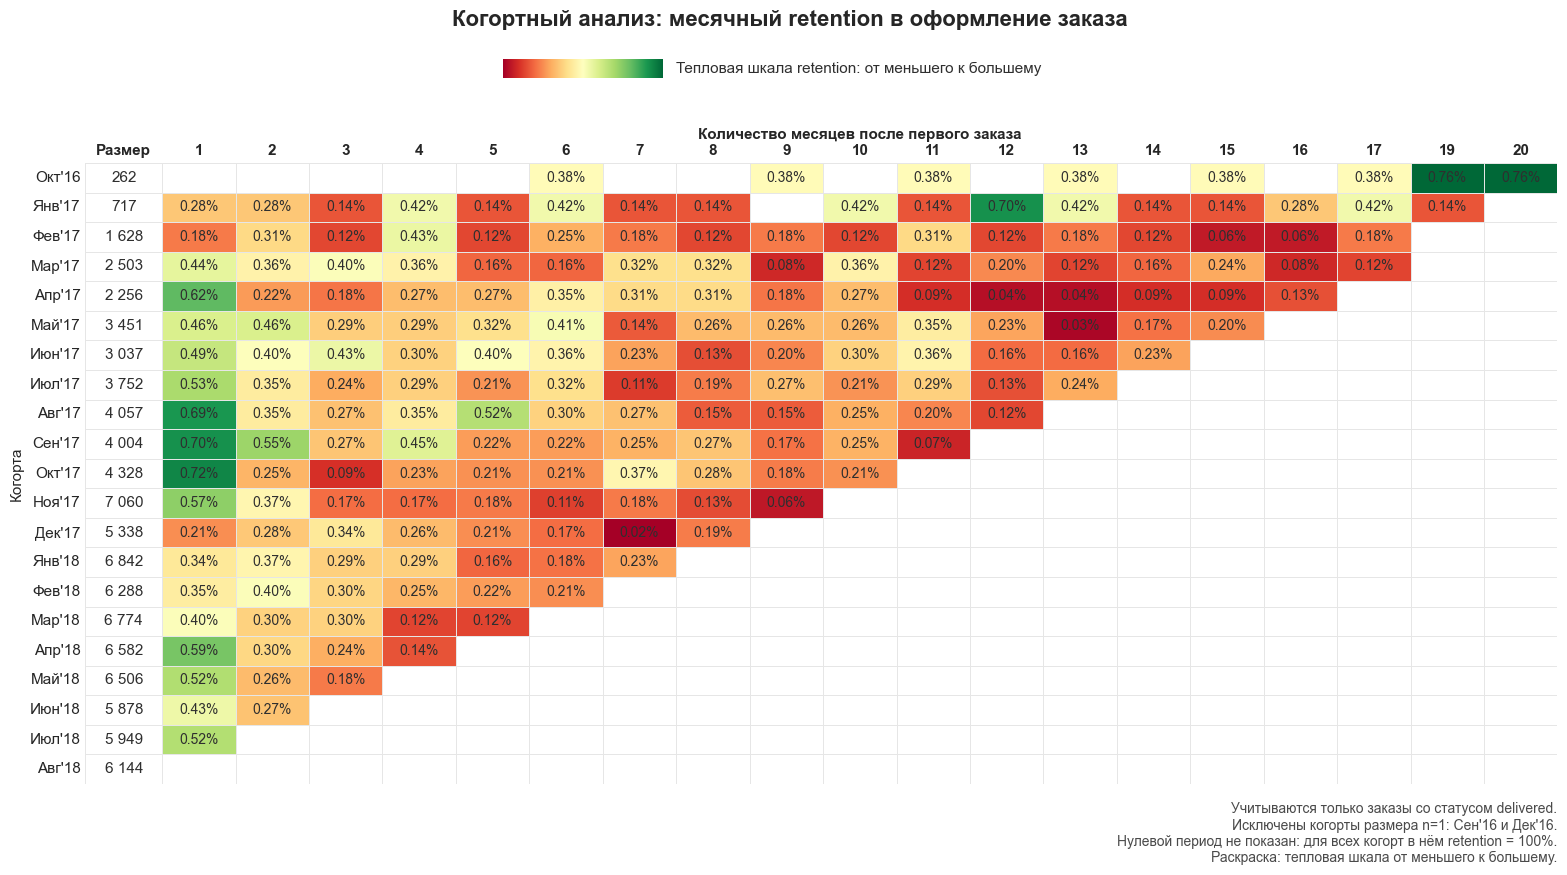

In [33]:
# ===================== КАРТА 1 =====================
MAIN_TITLE = "Когортный анализ: месячный retention в оформление заказа"

LEGEND_TEXT = "Тепловая шкала retention: от меньшего к большему"

XLABEL = "Количество месяцев после первого заказа"
YLABEL_LEFT = "Когорта"
SIZE_COL_RU = "Размер"

FOOTNOTE_MAP1 = (
    "Учитываются только заказы со статусом delivered.\n"
    "Исключены когорты размера n=1: Сен'16 и Дек'16.\n"
    "Нулевой период не показан: для всех когорт в нём retention = 100%.\n"
    "Раскраска: тепловая шкала от меньшего к большему."
)

# ===================== Данные для карты 1 =====================
cohort_size_df = cz.to_frame(name=SIZE_COL_RU)
annot_size = cohort_size_df.map(
    lambda x: f"{int(round(x)):,}".replace(",", " ") if pd.notna(x) else ""
)

# ===================== Рисование — КАРТА 1 =====================
white_cmap = mcolors.ListedColormap(["white"])

# Параметры сетки — как в КАРТЕ 2
GRID_LW = 0.5
GRID_COLOR = "#e6e6e6"

if ret_disp.shape[1] == 0:
    print("Нет столбцов периодов для отображения.")
else:
    fig = plt.figure(figsize=(16, 9))

    # Заголовок
    fig.text(
        0.5, 0.97, MAIN_TITLE,
        ha="center", va="top", fontsize=16, fontweight="bold",
        transform=fig.transFigure,
    )

    # --- Компактная легенда по центру: полоска + подпись справа от неё ---
    y_line = 0.905
    bar_width = 0.10
    bar_height = 0.022
    text_gap = 0.008
    # Примерная ширина текста легенды (подобрано для fontsize=11 при figsize=(16,9))
    legend_text_width = 0.25
    total_width = bar_width + text_gap + legend_text_width
    bar_left = 0.5 - total_width / 2

    ax_grad = fig.add_axes([bar_left, y_line - bar_height / 2, bar_width, bar_height])
    grad = np.linspace(0, 1, 256).reshape(1, -1)
    ax_grad.imshow(grad, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
    ax_grad.set_axis_off()

    fig.text(
        bar_left + bar_width + text_gap, y_line, LEGEND_TEXT,
        ha="left", va="center", fontsize=11, color="#2f2f2f",
        transform=fig.transFigure,
    )

    # --- Сама карта (gridspec — как в КАРТЕ 2) ---
    gs = fig.add_gridspec(
        1, 2,
        left=0.06, right=0.98, top=0.80, bottom=0.11,
        wspace=0,
        width_ratios=[0.55, 10],
    )
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
    for ax in (ax0, ax1):
        ax.grid(False)

    # Левая таблица: размеры когорт
    sns.heatmap(
        cohort_size_df,
        annot=annot_size,
        fmt="",
        cmap=white_cmap,
        cbar=False,
        linewidths=GRID_LW,
        linecolor=GRID_COLOR,
        ax=ax0,
        annot_kws={"fontsize": 11, "color": "#2f2f2f"},
    )
    ax0.set_title("")
    ax0.xaxis.tick_top()
    ax0.xaxis.set_label_position("top")
    ax0.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, length=0)
    ax0.set_xlabel("")
    ax0.set_ylabel(YLABEL_LEFT, fontsize=11)
    plt.setp(ax0.get_xticklabels(), rotation=0, fontsize=11, fontweight="bold")
    plt.setp(ax0.get_yticklabels(), rotation=0, fontsize=11)

    # Правая карта retention
    sns.heatmap(
        ret_disp,
        mask=ret_disp.isnull(),
        annot=annot_disp,
        fmt="",
        cmap="RdYlGn",
        cbar=False,
        linewidths=GRID_LW,
        linecolor=GRID_COLOR,
        ax=ax1,
        annot_kws={"fontsize": 10, "color": "#2f2f2f"},
    )
    ax1.set_title("")
    ax1.xaxis.tick_top()
    ax1.xaxis.set_label_position("top")
    ax1.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, length=0)
    ax1.set_xlabel(XLABEL, fontsize=11, fontweight="bold")
    ax1.set_ylabel("")
    plt.setp(ax1.get_xticklabels(), rotation=0, fontsize=11, fontweight="bold")
    ax1.tick_params(left=False, labelleft=False)

    # Сноска
    fig.text(
        0.98, 0.02, FOOTNOTE_MAP1,
        ha="right", va="bottom", fontsize=10, color="#4a4a4a",
        transform=fig.transFigure,
    )
    plt.show()

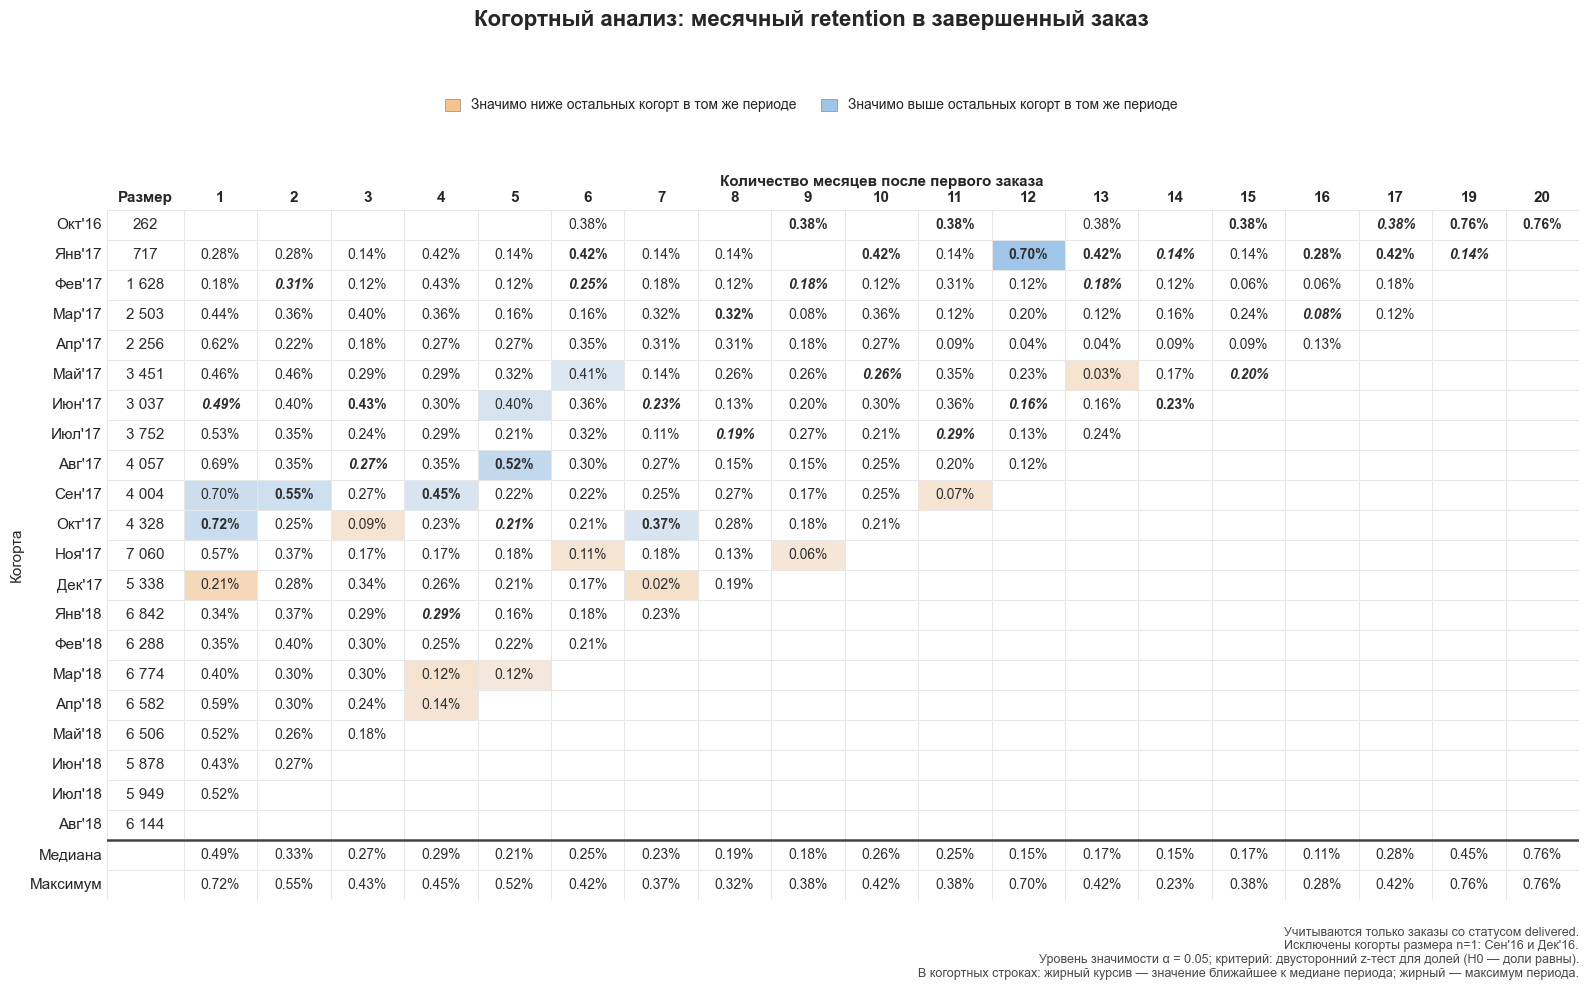

In [34]:
# ===================== КАРТА 2 =====================
MAIN_TITLE   = "Когортный анализ: месячный retention в завершенный заказ"
XLABEL       = "Количество месяцев после первого заказа"
YLABEL_LEFT  = "Когорта"
ALPHA        = 0.05
LEGEND_SIG_LOW  = "Значимо ниже остальных когорт в том же периоде"
LEGEND_SIG_HIGH = "Значимо выше остальных когорт в том же периоде"
FOOTNOTE_MAP2 = (
    "Учитываются только заказы со статусом delivered.\n"
    "Исключены когорты размера n=1: Сен'16 и Дек'16.\n"
    f"Уровень значимости α = {ALPHA:g}; критерий: двусторонний z-тест для долей (H0 — доли равны).\n"
    "В когортных строках: жирный курсив — значение ближайшее к медиане периода; жирный — максимум периода."
)

neg_color   = "#f6c28b"
mid_color   = "#f4f4f4"
pos_color   = "#9fc5e8"
cohort_cmap = LinearSegmentedColormap.from_list(
    "cohort_soft_diverging", [neg_color, mid_color, pos_color]
)
white_cmap = mcolors.ListedColormap(["white"])
GRID_LW    = 0.5
GRID_COLOR = "#e6e6e6"

# ---- Строки Медиана и Максимум ----
n_cohorts = len(ret_disp)   # количество когортных строк (без summary)

median_series    = ret_disp.median(axis=0, skipna=True)
max_series       = ret_disp.max(axis=0, skipna=True)
median_annot_ser = median_series.map(lambda x: f"{x*100:.2f}%" if pd.notna(x) else "")
max_annot_ser    = max_series.map(   lambda x: f"{x*100:.2f}%" if pd.notna(x) else "")

nan_row = pd.Series(np.nan, index=sig_disp.columns)

ret_disp_ext   = pd.concat([ret_disp,
                             pd.DataFrame([median_series],    index=["Медиана"]),
                             pd.DataFrame([max_series],       index=["Максимум"])])
annot_disp_ext = pd.concat([annot_disp,
                             pd.DataFrame([median_annot_ser], index=["Медиана"]),
                             pd.DataFrame([max_annot_ser],    index=["Максимум"])])
sig_disp_ext   = pd.concat([sig_disp,
                             pd.DataFrame([nan_row], index=["Медиана"]),
                             pd.DataFrame([nan_row], index=["Максимум"])])
cohort_size_ext = pd.concat([
    cohort_size_df,
    pd.DataFrame({SIZE_COL_RU: [np.nan]}, index=["Медиана"]),
    pd.DataFrame({SIZE_COL_RU: [np.nan]}, index=["Максимум"]),
])
annot_size_ext = cohort_size_ext.map(
    lambda x: f"{int(round(x)):,}".replace(",", " ") if pd.notna(x) else "—"
)

n_rows_total = len(ret_disp_ext)   # = n_cohorts + 2

# ----Вычисляем позиции медианы и максимума по каждому столбцу ----
# Для каждого периода (столбца j) ищем строки-когорты с ближайшим к медиане и с макс. значением
median_cell = {}   # {col_idx: row_idx}  — cohort row closest to period median
max_cell    = {}   # {col_idx: row_idx}  — cohort row with max value in period

for j, col in enumerate(ret_disp.columns):
    col_vals = ret_disp.iloc[:, j].dropna()
    if col_vals.empty:
        continue
    med = col_vals.median()
    closest_label = col_vals.sub(med).abs().idxmin()
    median_cell[j] = ret_disp.index.get_loc(closest_label)
    max_label    = col_vals.idxmax()
    max_cell[j]  = ret_disp.index.get_loc(max_label)

if ret_disp_ext.shape[1] == 0:
    print("Нет столбцов периодов для отображения.")
else:
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(
        1, 2,
        left=0.06, right=0.98, top=0.79, bottom=0.10,
        wspace=0,
        width_ratios=[0.55, 10],
    )
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
    for ax in (ax0, ax1):
        ax.grid(False)

    # Левая панель: размеры когорт
    sns.heatmap(cohort_size_ext, annot=annot_size_ext, fmt="", cmap=white_cmap,
                cbar=False, linewidths=GRID_LW, linecolor=GRID_COLOR, ax=ax0,
                annot_kws={"fontsize": 11, "color": "#2f2f2f"})

    # Основная карта retention (белый фон + аннотации)
    sns.heatmap(ret_disp_ext, mask=ret_disp_ext.isnull(), annot=annot_disp_ext,
                fmt="", cmap=white_cmap, cbar=False,
                linewidths=GRID_LW, linecolor=GRID_COLOR, ax=ax1,
                annot_kws={"fontsize": 10, "color": "#2f2f2f"})

    # Поверх — значимые отклонения (summary-строки замаскированы NaN)
    sns.heatmap(sig_disp_ext, mask=sig_disp_ext.isnull(), annot=False,
                cmap=cohort_cmap, center=0, vmin=-v, vmax=v,
                cbar=False, linewidths=GRID_LW, linecolor=GRID_COLOR, ax=ax1)

    # ---- Форматирование текстов: позиция определяет роль ячейки ----
    # Центр ячейки (row_idx, col_idx) → x = col_idx + 0.5, y = row_idx + 0.5
    for t in ax1.texts:
        x, y   = t.get_position()
        r, c   = int(y), int(x)   # row и col индексы (0-based)

        if r >= n_cohorts:
            # summary-строки (Медиана / Максимум) — обычный шрифт
            t.set_fontweight("normal")
            t.set_fontstyle("normal")
        elif c in max_cell and r == max_cell[c]:
            # Максимум периода — жирный
            t.set_fontweight("bold")
            t.set_fontstyle("normal")
        elif c in median_cell and r == median_cell[c]:
            # Ближайшее к медиане периода — жирный курсив
            t.set_fontweight("bold")
            t.set_fontstyle("italic")

    # ---- Разделительная линия между когортами и summary ----
    ax1.axhline(y=n_cohorts, color="#444", linewidth=1.8)
    ax0.axhline(y=n_cohorts, color="#444", linewidth=1.8)

    # Оформление левой оси
    ax0.set_title("")
    ax0.xaxis.tick_top(); ax0.xaxis.set_label_position("top")
    ax0.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, length=0)
    ax0.set_xlabel(""); ax0.set_ylabel(YLABEL_LEFT, fontsize=11)
    plt.setp(ax0.get_xticklabels(), rotation=0, fontsize=11, fontweight="bold")
    plt.setp(ax0.get_yticklabels(), rotation=0, fontsize=11)

    # Оформление правой оси
    ax1.set_title("")
    ax1.xaxis.tick_top(); ax1.xaxis.set_label_position("top")
    ax1.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, length=0)
    ax1.set_xlabel(XLABEL, fontsize=11, fontweight="bold"); ax1.set_ylabel("")
    plt.setp(ax1.get_xticklabels(), rotation=0, fontsize=11, fontweight="bold")
    ax1.tick_params(left=False, labelleft=False)

    # Заголовок
    fig.text(0.5, 0.99, MAIN_TITLE, ha="center", va="top",
             fontsize=16, fontweight="bold", transform=fig.transFigure)

    # Легенда
    fig.legend(
        handles=[
            Patch(facecolor=neg_color, edgecolor="#999", linewidth=0.6, label=LEGEND_SIG_LOW),
            Patch(facecolor=pos_color, edgecolor="#999", linewidth=0.6, label=LEGEND_SIG_HIGH),
        ],
        loc="lower center", bbox_to_anchor=(0.5, 0.875), ncol=2,
        frameon=False, fontsize=10, handlelength=1.1, handleheight=1.0, columnspacing=1.8,
    )

    # Сноска
    fig.text(0.98, 0.02, FOOTNOTE_MAP2,
             ha="right", va="bottom", fontsize=9, color="#4a4a4a",
             transform=fig.transFigure)

    plt.show()

In [36]:

# Для расчётов используем только когорты с n > 1
ret_full = retention_matrix.loc[valid_cohorts]

# --- 1) Медианный retention 1-го месяца ---
m1 = ret_full[1].dropna()
m1_median = m1.median()

print(f"Медианный retention 1-го месяца (M1): {m1_median * 100:.2f}%")

# --- 2) Когорта с самым высоким retention на 3-й месяц ---
m3 = ret_full[3].dropna()
best_cohort_m3 = m3.idxmax()
best_value_m3 = m3.max()

print(f"Когорта с самым высоким retention на 3-й месяц (M3) {best_value_m3 * 100:.2f}%")

Медианный retention 1-го месяца (M1): 0.49%
Когорта с самым высоким retention на 3-й месяц (M3) 0.43%


In [37]:
# Диагностика: почему retention такой низкий
total_customers_unique = flt_orders["customer_unique_id"].nunique()
total_orders = flt_orders["order_id"].nunique()

orders_per_customer = (
    flt_orders.groupby("customer_unique_id")["order_id"]
    .nunique()
)

# 1) Сколько заказов на одного уникального покупателя
print("=" * 60)
print("Активность покупателей (только delivered)")
print("=" * 60)
print(f"Уникальных покупателей: {total_customers_unique:,}".replace(",", " "))
print(f"Уникальных заказов:     {total_orders:,}".replace(",", " "))
print(f"Заказов на покупателя в среднем: {total_orders / total_customers_unique:.3f}")

# 2) Распределение: сколько у пользователя заказов
dist = orders_per_customer.value_counts().sort_index()
share = (dist / dist.sum() * 100).round(2)
print()
print("Распределение покупателей по числу заказов:")
print(pd.DataFrame({"clients": dist, "share_%": share}).head(10).to_string())

# 3) Доля повторных покупателей
repeat_customers = (orders_per_customer >= 2).sum()
repeat_rate = repeat_customers / total_customers_unique
print()
print(f"Покупателей с >= 2 заказами: {repeat_customers:,}".replace(",", " "))
print(f"Repeat rate (доля вернувшихся когда-либо): {repeat_rate * 100:.2f}%")

Активность покупателей (только delivered)
Уникальных покупателей: 93 358
Уникальных заказов:     96 478
Заказов на покупателя в среднем: 1.033

Распределение покупателей по числу заказов:
          clients  share_%
order_id                  
1           90557    97.00
2            2573     2.76
3             181     0.19
4              28     0.03
5               9     0.01
6               5     0.01
7               3     0.00
9               1     0.00
15              1     0.00

Покупателей с >= 2 заказами: 2 801
Repeat rate (доля вернувшихся когда-либо): 3.00%


### Задача 2. Определить, существует ли product/market fit у маркетплейса

Построив retention, вы решили оценить, насколько хорошо продукт закрывает потребности клиента.

Для этого вам нужно определить, существует ли product/market fit у этого маркетплейса. До сих пор непонятно, можно ли масштабировать подобный продукт на новые рынки, и есть риск, что маркетплейс будет приносить убытки.

В рамках исследования необходимо:

- Оценить наличие product/market fit у данного продукта с помощью когортного анализа, полученного на предыдущем шаге.
- Пояснить свою позицию и сформулировать, на чём маркетплейс должен сконцентрироваться в ближайшее время.
- Если PMF есть, определить, в какую сторону лучше развивать продукт дальше

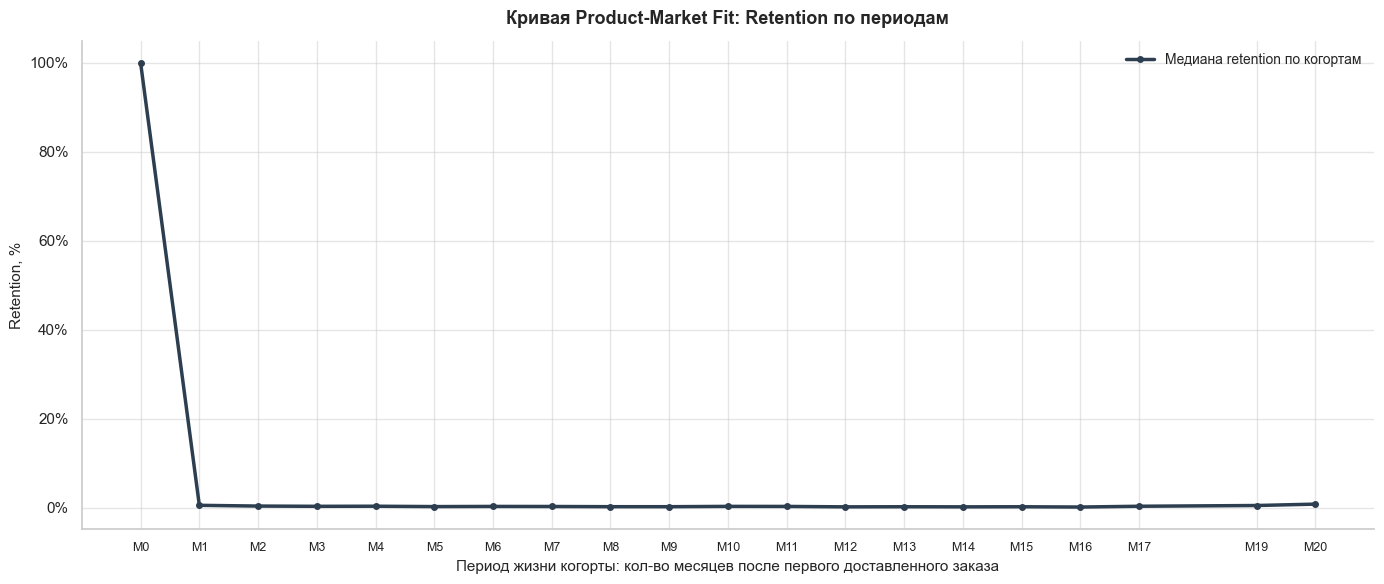

In [38]:
# КРИВАЯ PRODUCT-MARKET FIT
# Классическая форма: M0 = 100% (первая покупка), затем кривая падает.
# «Полка» на ненулевом уровне = PMF есть. Кривая уходит к нулю = PMF нет.

pmf_periods = sorted([p for p in ret_full.columns
                      if isinstance(p, (int, np.integer)) and p >= 0])

# Медиана по каждому периоду (M0 = 1.0 = 100% по определению)
median_pmf = pd.Series(
    {p: (ret_full[p].dropna().median() * 100 if p > 0 else 100.0)
     for p in pmf_periods if p in ret_full.columns}
).dropna()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(median_pmf.index, median_pmf.values,
        color="#2c3e50", linewidth=2.5, marker="o", markersize=4,
        label="Медиана retention по когортам", zorder=5)

# Ось X: M0, M1, M2, ..., Mmax
ax.set_xticks(pmf_periods)
ax.set_xticklabels([f"M{p}" for p in pmf_periods], fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.set_xlabel(
    "Период жизни когорты: кол-во месяцев после первого доставленного заказа",
    fontsize=11
)
ax.set_ylabel("Retention, %", fontsize=11)
ax.set_title(
    "Кривая Product-Market Fit: Retention по периодам",
    fontsize=13, fontweight="bold", pad=12,
)
ax.legend(frameon=False, fontsize=10, loc="upper right")
ax.set_axisbelow(True)
sns.despine()
plt.tight_layout()
plt.show()

### Когортный анализ и product/market fit: выводы

Когортный анализ показывает, что retention находится на крайне низком уровне: медианный retention первого месяца не поднимается выше 0.5%, а максимальные значения по когортам остаются ниже 1%. На кривой product/market fit нет устойчивого плато: сразу после M0 показатель падает ниже 1%, что указывает на быстрый отток пользователей.

**Выводы:**

- Уровень удержания критически низкий.
- Подавляющее большинство покупателей (97%) не возвращается в маркетплейс после первой покупки.
- Повторный заказ совершают только 3% покупателей.
- Среднее количество заказов на одного покупателя — около 1.

Маркетплейс живёт за счёт постоянного притока новых клиентов, а не за счёт удержания существующих. Для классической модели маркетплейса это критичный сигнал: обычно рост опирается на повторные покупки и LTV, а не только на привлечение нового трафика.

Низкий retention может означать отсутствие product/market fit: продукт не полностью закрывает потребности клиентов и/или не создаёт достаточной ценности относительно альтернатив.

**Рекомендации:**

- Не масштабировать продукт, пока не растут retention и конверсия в повторную покупку.
- Проверить юнит-экономику: соотношение CAC, валовой прибыли и горизонта окупаемости.
- Сфокусироваться на PMF: диагностировать клиентский путь после первого заказа и тестировать гипотезы роста повторного спроса.

**Какие проблемы можно исследовать:**

1. Каталог и ассортимент: соответствие предложения спросу, уровень цен.
2. UX: удобство поиска, качество карточек товаров, полнота информации о товаре, простота оформления заказа.
3. Сервис: сроки и стоимость доставки, удобство расположения ПВЗ/интервалов доставки, простота возврата.
4. Удержание и работа с CRM: рекомендации, персональные рассылки, механики возврата на повторную покупку.
5. Сегменты аудитории: поведение в разрезе географии, чека и категорий товаров.

### Задача 3. Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

Вы разобрались с наличием product/market fit. Теперь вас просят сформулировать продуктовые метрики маркетплейса, чтобы компания могла на них ориентироваться.

В первую очередь необходимо:

Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

- Первая метрика должна отражать рост объёма продаж маркетплейса.
- Вторая — показывать объем аудитории, которой продукт доставляет ценность.
- Третья — отражать заинтересованность новых клиентов в продукте (даже если вы не можете посчитать ее на имеющихся у вас данных).
- Четвёртая — отражать вовлеченность клиента в продолжение использования продукта.
- Пятая — отражать денежное выражение вовлеченности клиента.

Визуализируйте первую, вторую, четвёртую и пятую метрики. Используйте месячную гранулярность и окно в 1 месяц, если это нужно.

In [39]:

#копия df дата в нужном формате
df = flt_orders.copy()
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')
# только delivered-заказы
delivered = df[df['order_status'] == 'delivered'].copy()
#  Месяц ПОКУПКИ (а не доставки)
delivered['purchase_month'] = delivered['order_purchase_timestamp'].dt.to_period('M')
#  Кол-во delivered-заказов по месяцу покупки
delivered_orders_by_month = (
    delivered
    .groupby('purchase_month')
    .agg(delivered_orders=('order_id', 'nunique'))  # если order_id уникален, можно и count()
    .sort_index()
)
# Опционально: сглаживание 3-месячным скользящим средним
delivered_orders_by_month['delivered_orders_ma3'] = (
    delivered_orders_by_month['delivered_orders']
    .rolling(window=3, min_periods=1)
    .mean()
)
# Посмотреть таблицу
display(delivered_orders_by_month.head(12))


,delivered_orders,delivered_orders_ma3
purchase_month,,
2016-09,1,1.000000
2016-10,265,133.000000
2016-12,1,89.000000
2017-01,750,338.666667
2017-02,1653,801.333333
2017-03,2546,1649.666667
2017-04,2303,2167.333333
2017-05,3546,2798.333333
2017-06,3135,2994.666667


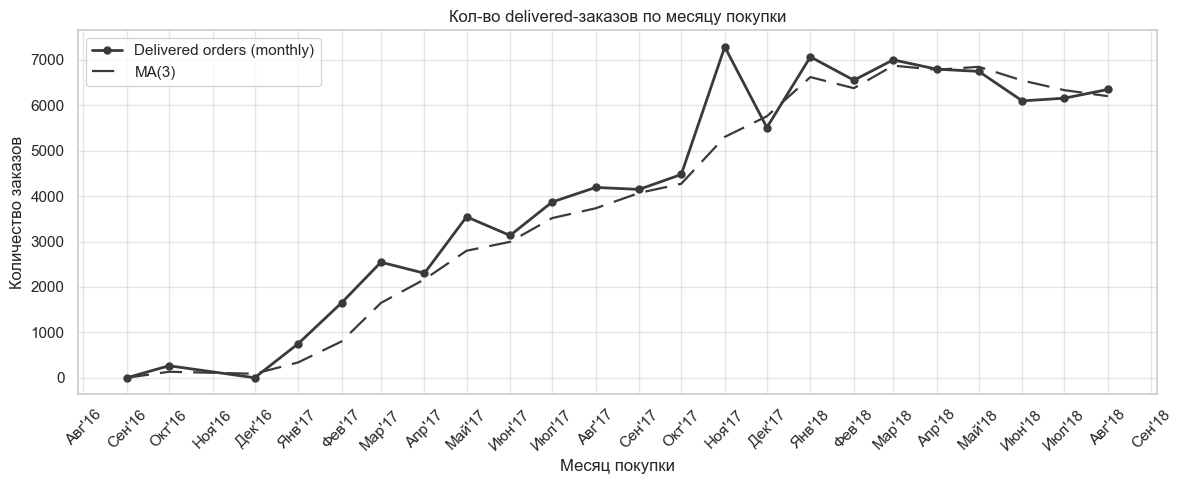

In [45]:
plot_df["delivered_orders_ma3"] = (
    plot_df["delivered_orders"].rolling(window=3, min_periods=1).mean()
)

LINE_COLOR = "#3A3A3A"

plot_df = delivered_orders_by_month.copy()
plot_df = plot_df.sort_index()
plot_df.index = plot_df.index.to_timestamp(how="start")

RU_MONTH_SHORT = {
    1: "янв", 2: "фев", 3: "мар", 4: "апр", 5: "май", 6: "июн",
    7: "июл", 8: "авг", 9: "сен", 10: "окт", 11: "ноя", 12: "дек",
}


def format_ru_month_year(x, pos=None):
    dt = mdates.num2date(x).replace(tzinfo=None)
    mon = RU_MONTH_SHORT[dt.month].capitalize()
    return f"{mon}'{dt.year % 100:02d}"


sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 5))

x = plot_df.index

ax.plot(
    x,
    plot_df["delivered_orders"],
    color=LINE_COLOR,
    linestyle="-",
    linewidth=2.0,
    marker="o",
    markersize=5,
    label="Delivered orders (monthly)",
    zorder=3,
)

ax.plot(
    x,
    plot_df["delivered_orders_ma3"],
    color=LINE_COLOR,
    linestyle=(0, (10, 5)),
    linewidth=1.6,
    label="MA(3)",
    zorder=2,
)

ax.set_title("Кол-во delivered-заказов по месяцу покупки")
ax.set_xlabel("Месяц покупки")
ax.set_ylabel("Количество заказов")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_ru_month_year))
ax.tick_params(axis="x", rotation=45)

ax.legend()
plt.tight_layout()
plt.show()

Хорошая метрика должна быть:
чувствительной к изменениям,
стабильной (меньше внешнего шума),
интерпретируемой.




Это прям критерий выбора, им удобно “проверять” твои 5 метрик.
Источник: тот же конспект (стр. 13).
Для структуры 5 метрик удобно опираться на AARRR-этапы: acquisition, activation, retention, referral, revenue.
Тогда каждая метрика закрывает свой участок пути клиента, а не дублирует соседнюю.
Источник: тот же конспект (стр. 13–24).

По retention/PMF: в конспекте явно сказано, что для PMF важен выход retention на плато.
И важно заранее выбрать правильную гранулярность (день/неделя/месяц) под тип продукта.
Источник: тот же конспект (стр. 19–23).

Для денежной метрики вовлеченности из примеров рекомендуют смотреть ARPU/ARPPU/LTV (в зависимости от того, что доступно в данных).
Источник: тот же конспект (стр. 23–24).

Для перехода к задаче с гипотезами: в ICE-конспекте важная мысль — impact оценивается через изменение выбранной метрики и размер сегмента, где есть проблема.
То есть метрика должна быть такой, чтобы изменение можно было количественно оценить.
Источник: 12.4.product_hypotheses/theory/Конспект 4 урок Работа с продуктовыми гипотезами.pdf (стр. 8–10).

In [55]:
###метрика объема продаж
#сумма по заказам
order_sums = (order_items
                 .groupby('order_id', as_index=False)
                 .agg(order_sum=("price", "sum")))
order_sums

,order_id,order_sum
0,00010242fe8c5a6d1ba2dd792cb16214,58.90
1,00018f77f2f0320c557190d7a144bdd3,239.90
2,000229ec398224ef6ca0657da4fc703e,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90
...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,299.99
98662,fffcd46ef2263f404302a634eb57f7eb,350.00
98663,fffce4705a9662cd70adb13d4a31832d,99.90
98664,fffe18544ffabc95dfada21779c9644f,55.99


In [56]:
#Проверка, нет ли дубликатов строк по заказам в таблице orders - дубликатов нет
orders["order_id"].duplicated().sum()

np.int64(0)

In [84]:
orders.order_status.value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [67]:
#фильтр на статус заказа
mask = ~orders["order_status"].isin(["canceled", "unavailable", "processing","created", "approved"])
orders_totals = (
    orders.loc[mask]
    .copy()
    .merge(orders_sums, how = "left", on = "order_id"))
orders_with_totals.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_sum
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90


In [68]:
orders_totals.order_status.value_counts()

order_status
delivered    96478
shipped       1107
invoiced       314
Name: count, dtype: int64

In [75]:
#суммирую общую стоимость заказов по месяцам
order_totals_by_month = (
    orders_totals.assign(order_month=orders_totals["order_purchase_timestamp"].dt.to_period("M"))
    .groupby("order_month", as_index=False)
    .agg(orders_total=("order_sum", "sum"))
)
order_totals_by_month

,order_month,orders_total
0,2016-09,207.86
1,2016-10,44145.30
2,2016-12,10.90
3,2017-01,117781.71
4,2017-02,239059.29
5,2017-03,363601.87
6,2017-04,347879.93
7,2017-05,499417.22
8,2017-06,427600.89
9,2017-07,490801.42


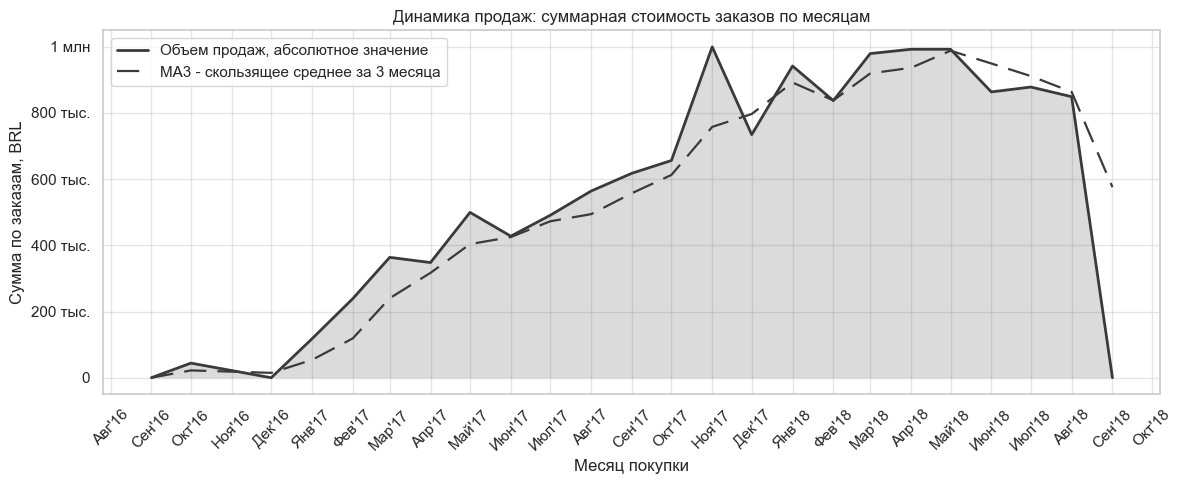

In [83]:
def human_ru_thousands_or_millions(v, _pos=None):
    """Удобно читаемые подписи: тыс. до миллиона, млн от миллиона."""
    if v is None:
        return ""

    av = abs(v)
    sign = "-" if v < 0 else ""

    if av >= 1_000_000:
        x = av / 1_000_000
        # 1.0 млн, 1.2 млн; без лишнего .0 для целых (опционально)
        s = f"{x:.1f}".rstrip("0").rstrip(".")
        return f"{sign}{s} млн"

    if av >= 1_000:
        x = av / 1_000
        s = f"{x:.0f}" if abs(x - round(x)) < 1e-9 else f"{x:.1f}".rstrip("0").rstrip(".")
        return f"{sign}{s} тыс."

    return f"{sign}{av:.0f}"

RU_MONTH_SHORT = {
    1: "янв", 2: "фев", 3: "мар", 4: "апр", 5: "май", 6: "июн",
    7: "июл", 8: "авг", 9: "сен", 10: "окт", 11: "ноя", 12: "дек",
}
def format_ru_month_year(x, pos=None):
    """Даты в удобном для чтения формате"""
    dt = mdates.num2date(x).replace(tzinfo=None)
    mon = RU_MONTH_SHORT[dt.month].capitalize()
    return f"{mon}'{dt.year % 100:02d}"


LINE_COLOR = "#3A3A3A"
FILL_COLOR = "#3A3A3A"
ALPHA = 0.18  # прозрачность заливки

plot_df = order_totals_by_month.sort_values("order_month").copy()
plot_df["order_month_ts"] = plot_df["order_month"].dt.to_timestamp(how="start")
plot_df["orders_total_ma3"] = plot_df["orders_total"].rolling(window=3, min_periods=1).mean()

sns.set(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 5))

x = plot_df["order_month_ts"]
y = plot_df["orders_total"]

ax.fill_between(x, y, color=FILL_COLOR, alpha=ALPHA, linewidth=0)
ax.plot(x, y, color=LINE_COLOR, linewidth=2.0, label="Объем продаж, абсолютное значение")
ax.plot(
    x,
    plot_df["orders_total_ma3"],
    color=LINE_COLOR,
    linestyle=(0, (10, 5)),
    linewidth=1.6,
    label="MA3 - скользящее среднее за 3 месяца",
)
ax.legend()

ax.set_title("Динамика продаж: суммарная стоимость заказов по месяцам")
ax.set_xlabel("Месяц покупки")
ax.set_ylabel("Сумма по заказам, BRL")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_ru_month_year))
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(human_ru_thousands_or_millions))
ax.yaxis.offsetText.set_visible(False)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

<sup>*</sup> **
** в расчёт включены только заказы со статусами: `delivered`,`shipped` и `invoiced`.
Не включаются заказы со статусами: `canceled`, `unavailable`, `processing`, `created` и `approved`.

В качестве метрики роста объёма продаж я использую месячную сумму стоимости заказов в BRL (бразильские реалы: для каждого order_id (идентификатор заказа)** суммирую **price (цена)** по всем строкам из **olist_order_items (позиции заказа)**, затем агрегирую по **месяцу покупки** из **order_purchase_timestamp (дата и время оформления заказа). На графике дополнительно показана линия MA(3) - скользящее среднее за 3 месяца - это тренд, в котором сглажены сезонные колебания

В расчёт включены заказы со статусами delivered (доставлен), shipped (отгружен / в пути) и invoiced (выставлен счёт); исключены canceled (отменён), unavailable (недоступен товар), processing (в обработке), created (создан) и approved (подтверждён)** — чтобы метрика отражала **объём оформленных продаж**.

In [92]:
# Вторая метрика должна показывать объем аудитории, которой продукт доставляет ценность.

mask = ~orders["order_status"].isin(["canceled", "unavailable", "processing","created", "approved"])
orders_successful = orders.loc[mask].copy()
# orders_successful["order_purchase_timestamp"] = pd.to_datetime(orders_successful["order_purchase_timestamp"], errors="coerce")
orders_successful["order_month"] = orders_successful["order_purchase_timestamp"].dt.to_period("M")
orders_successful.head()

customers_by_month = (orders_successful
                      .merge(customers[['customer_unique_id','customer_id']], how="left", on="customer_id")
                      .groupby('order_month', as_index = False)
                      .agg(mau=("customer_unique_id", "nunique"))
                      )
customers_by_month


,order_month,mau
0,2016-09,2
1,2016-10,288
2,2016-12,1
3,2017-01,744
4,2017-02,1662
5,2017-03,2554
6,2017-04,2334
7,2017-05,3548
8,2017-06,3130
9,2017-07,3863


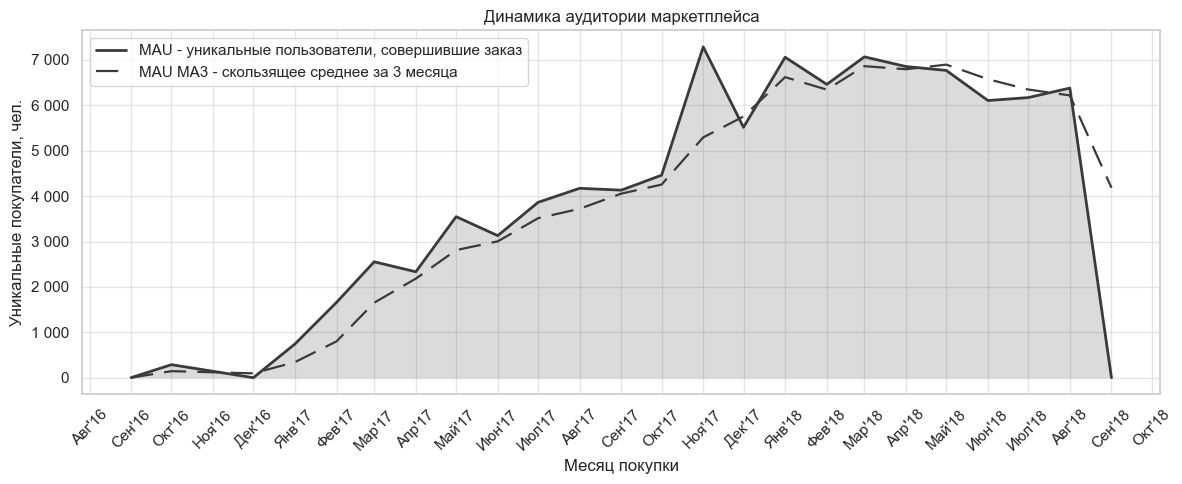

In [95]:
#
def format_users_ru(v, _pos=None):
    """Подписи оси Y числа юзеров: целые значения, разделитель тысяч пробелом (без 'тыс.')."""
    if v is None:
        return ""
    v = int(round(v))
    sign = "-" if v < 0 else ""
    v = abs(v)
    return sign + f"{v:,}".replace(",", " ")


plot_mau = customers_by_month.sort_values("order_month").copy()
plot_mau["order_month_ts"] = plot_mau["order_month"].dt.to_timestamp(how="start")
plot_mau["mau_ma3"] = plot_mau["mau"].rolling(window=3, min_periods=1).mean()

sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 5))

x = plot_mau["order_month_ts"]
y = plot_mau["mau"]

ax.fill_between(x, y, color=FILL_COLOR, alpha=ALPHA, linewidth=0)
ax.plot(x, y, color=LINE_COLOR, linewidth=2.0, label="MAU - уникальные пользователи, совершившие заказ")
ax.plot(
    x,
    plot_mau["mau_ma3"],
    color=LINE_COLOR,
    linestyle=(0, (10, 5)),
    linewidth=1.6,
    label="MAU MA3 - скользящее среднее за 3 месяца",
)
ax.legend()

ax.set_title("Динамика аудитории маркетплейса")
ax.set_xlabel("Месяц покупки")
ax.set_ylabel("Уникальные покупатели, чел.")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_ru_month_year))

ax.ticklabel_format(axis="y", style="plain", useOffset=False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_users_ru))
ax.yaxis.offsetText.set_visible(False)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Третья метрика должна отражать заинтересованность новых клиентов в продукте (даже если вы не можете посчитать ее на имеющихся у вас данных).
Если у компании есть джанные о визитах/сессиях (заходы на сайт, просмотры карточек товаров, кликах по товарам), я предложила бы использовать одну из этих метрик:

- Конверсия в покупку среди новых посетителей: какая доля уникальных посетителей сайта доходит до целевого действия — оформления заказа.
- Конверсия от просмотра/клика до покупки: например, доля пользователей, которые посмотрели карточку товара (или нажали на товар), и затем оформи

- Эти  метрики связаны с релевантностью каталога и ассортимента для покупателей:  если клиенты не находят то, что соответствует их ожиданиям, или их не устраевает цена/условия доставки, конверсия новых посетителей в покупку снижается.

In [96]:
# Четвёртая метрика должна отражать вовлеченность клиента в продолжение использования продукта.
# Пятая метрика должна отражать денежное выражение вовлеченности клиента.
# 4. Доля возвращающихся покупателей в месяце (repeat buyer share, доля повторных покупателей)
# Смысл: показывает, среди клиентов, которые совершили заказ в текущем месяце, какая доля уже совершала заказ раньше
# Логика расчета: n уникальных customer_unique_id с заказом в месяце M/ n тех, у кого уже был сделан заказ в предыдущие месяцы
#
# 5. Доля GMV (Gross Merchandise Value, валовая стоимость товаров) от возвращающихся
# Смысл: показывает, какую процент от выручки за месяу принесли не новички, а вернувшиеся покупатели.
# Логика расчета: сумма order_sum (сумма заказа) по заказам месяца, где клиент - повторный покупатель/ order_sum  всего месяца

# Подготовка данных: месяц заказаimport pandas as pd

ALLOWED_STATUSES = ["delivered", "shipped", "invoiced"]  # как на графике продаж

# Фильтруем заказы по статусам и подтягиваем customer_unique_id
orders_success = (
    orders_totals
    .loc[orders_totals["order_status"].isin(ALLOWED_STATUSES),
         ["order_id", "order_status", "customer_id", "order_purchase_timestamp", "order_sum"]]
    .merge(
        customers[["customer_id", "customer_unique_id"]],
        how="left",
        on="customer_id",
    )
)

# Месяц заказа
orders_success["order_month"] = orders_success["order_purchase_timestamp"].dt.to_period("M")

# order_rank: какой по счету заказ у клиента (все месяцы подряд)
orders_success = orders_success.sort_values(
    ["customer_unique_id", "order_purchase_timestamp", "order_id"]
).copy()

orders_success["order_rank"] = (
    orders_success.groupby("customer_unique_id").cumcount() + 1
)

# Повторный заказ = 2-й и последующие (может быть и внутри того же месяца)
orders_success["is_repeat_order"] = orders_success["order_rank"] > 1

# Готовим агрегации по месяцам
# Доля возвращающихся покупателей в месяце:
# Покупатель считается returning в месяце, если в этом месяце он сделал >=1 повторный заказ
cust_month = (
    orders_success
    .groupby(["order_month", "customer_unique_id"], as_index=False)
    .agg(is_returning_customer=("is_repeat_order", "max"))
)

buyers_total_by_month = (
    cust_month.groupby("order_month")
    .agg(buyers_total=("customer_unique_id", "nunique"))
)

buyers_repeat_by_month = (
    cust_month.loc[cust_month["is_returning_customer"], :]
    .groupby("order_month")
    .agg(buyers_repeat=("customer_unique_id", "nunique"))
)

monthly_buyers = buyers_total_by_month.join(buyers_repeat_by_month, how="left")
monthly_buyers["buyers_repeat"] = monthly_buyers["buyers_repeat"].fillna(0)

monthly_buyers["repeat_buyer_share"] = (
    monthly_buyers["buyers_repeat"] / monthly_buyers["buyers_total"]
)

# Доля GMV от возвращающихся:
gmv_total_by_month = (
    orders_success.groupby("order_month")
    .agg(gmv_total=("order_sum", "sum"))
)

gmv_repeat_by_month = (
    orders_success.loc[orders_success["is_repeat_order"]]
    .groupby("order_month")
    .agg(gmv_repeat=("order_sum", "sum"))
)

monthly_gmv = gmv_total_by_month.join(gmv_repeat_by_month, how="left")
monthly_gmv["gmv_repeat"] = monthly_gmv["gmv_repeat"].fillna(0)

monthly_gmv["gmv_returning_share"] = (
    monthly_gmv["gmv_repeat"] / monthly_gmv["gmv_total"]
)

# Итоговая таблица метрик за месяцы
metrics_4_5_by_month = (
    monthly_buyers
    .join(monthly_gmv[["gmv_returning_share"]], how="left")
    .reset_index()
)

metrics_4_5_by_month["order_month_ts"] = metrics_4_5_by_month["order_month"].dt.to_timestamp(how="start")

metrics_4_5_by_month.head()

,order_month,buyers_total,buyers_repeat,repeat_buyer_share,gmv_returning_share,order_month_ts
0,2016-09,2,0.0,0.000000,0.000000,2016-09-01
1,2016-10,288,3.0,0.010417,0.010668,2016-10-01
2,2016-12,1,0.0,0.000000,0.000000,2016-12-01
3,2017-01,744,26.0,0.034946,0.021268,2017-01-01
4,2017-02,1662,23.0,0.013839,0.011266,2017-02-01


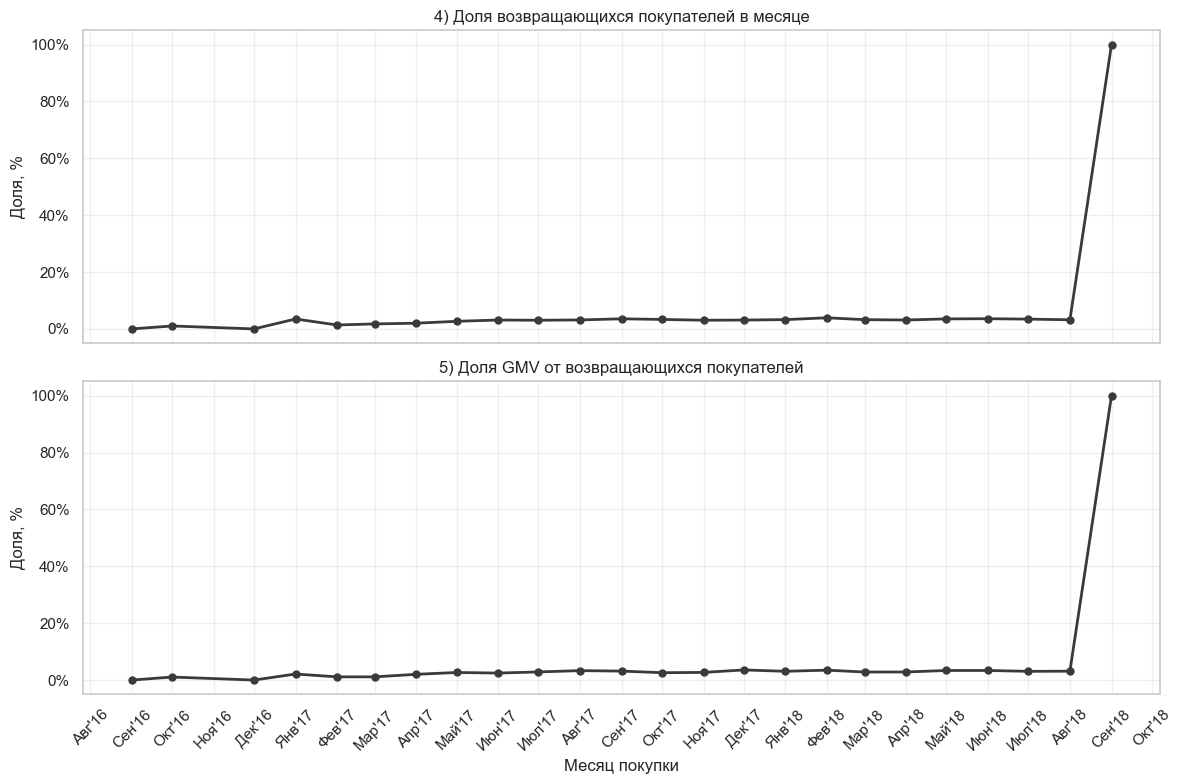

In [97]:
def format_percent(v, _pos=None):
    if v is None or pd.isna(v):
        return ""
    return f"{v * 100:.0f}%"

sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

x = metrics_4_5_by_month["order_month_ts"]

# 4) Доля возвращающихся покупателей
axes[0].plot(
    x,
    metrics_4_5_by_month["repeat_buyer_share"],
    color=LINE_COLOR,
    linewidth=2.0,
    marker="o",
    markersize=5,
)
axes[0].set_title("4) Доля возвращающихся покупателей в месяце")
axes[0].set_ylabel("Доля, %")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(format_percent))
axes[0].grid(alpha=0.3)

# 5) Доля GMV от возвращающихся
axes[1].plot(
    x,
    metrics_4_5_by_month["gmv_returning_share"],
    color=LINE_COLOR,
    linewidth=2.0,
    marker="o",
    markersize=5,
)
axes[1].set_title("5) Доля GMV от возвращающихся покупателей")
axes[1].set_ylabel("Доля, %")
axes[1].set_xlabel("Месяц покупки")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(format_percent))
axes[1].grid(alpha=0.3)

# Ось X: месяцы в формате "Сен'26"
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_ru_month_year))
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [98]:
tmp = orders_success.copy()
tmp["order_month"] = tmp["order_purchase_timestamp"].dt.to_period("M")

tmp = tmp.sort_values(["customer_unique_id", "order_purchase_timestamp", "order_id"])
tmp["order_rank"] = tmp.groupby("customer_unique_id").cumcount() + 1
tmp["is_returning_order"] = tmp["order_rank"] > 1

# Покупатель считается возвращающимся в месяце, если у него в этом месяце есть хотя бы 1 повторный заказ
cust_month = (
    tmp.groupby(["order_month", "customer_unique_id"], as_index=False)
       .agg(has_returning=("is_returning_order", "max"))
)

abs_check = (
    cust_month.groupby("order_month", as_index=False)
             .agg(
                 buyers_total=("customer_unique_id", "nunique"),
                 buyers_returning=("customer_unique_id", lambda s: cust_month.loc[s.index, "has_returning"].sum())
             )
)

abs_check.tail(10)

,order_month,buyers_total,buyers_returning
14,2017-12,5516,172
15,2018-01,7060,231
16,2018-02,6462,253
17,2018-03,7068,230
18,2018-04,6855,215
19,2018-05,6769,239
20,2018-06,6106,219
21,2018-07,6171,213
22,2018-08,6380,205
23,2018-09,1,1


По графикам метрик 4 (доля возвращающихся покупателей) и 5 (доля GMV от возвращающихся) видно, что повторные покупки составляют лишь небольшую часть покупок и почти не влияют на объём выручки GMV. Основные продажи идут за счёт новых клиентов, а вклад повторного спроса слабый.

В сентябре 2018 база очень низкая (один покупатель), поэтому доли резко растут, но интерпретировать этот всплеск нельзя из‑за недостаточного объёма данных.

Продуктовой команде стоит обратить внимание на повышение вероятности повторной покупки: усилить ценность после первой покупки (релевантность каталога и ассортимента, качество сервиса и доставки), а также настроить CRM и механики возврата на повтор. Если повторный спрос не начнёт расти, масштабирование будет зависеть только от привлечения новых пользователей и повысит финансовые риски.

### Задача 4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE

Посмотрев с продактом на когортный анализ и метрики, вы решили, что нужно изменить продукт. Метрики необходимо срочно повышать. Вместе с командой вы сформулировали 3 гипотезы, в которые вы верите. По каждой гипотезе команда заполнила показатели по Ease, Confidence. Вам нужно заполнить самый важный показатель — Impact. Для этого вам требуется:

1) Выбрать одну из трёх основных гипотез с помощью фреймворка ICE, которые были сформированы продактом и, кажется, должны улучшить пользовательский опыт в маркетплейсе.

2) Для расчёта Impact взять данные с **июня 2017** года. Считать, что конверсия в повторный заказ равна величине **медианного retention 1-го месяца** (см. пункт 1 проекта).

3) Для перевода метрики в Impact использовать следующую шкалу:

| Impact | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|---|---|---|---|---|---|---|---|---|---|---|
| Значение метрики | 0 - 50 | 51 - 150 | 151 - 350 | 351 - 750 | 751 - 1550 | 1551 - 3150 | 3151 - 6350 | 6351 - 12750 | 12751 - 25550 | 25551 - 51150 |

4) Заполнить итоговую строку для каждой гипотезы в формате:

| Гипотеза | Impact | Confidence | Ease | ICE |
|---|---:|---:|---:|---:|
| Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен. |  | 8 | 6 |  |
| Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов. |  | 10 | 4 |  |
| Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ. |  | 5 | 9 |  |

Логика работы:

- берём данные начиная с июня 2017,
- считаем, что конверсия в повторный заказ равна медианному retention 1-го месяца (то есть вероятность повторной покупки),
- для каждой гипотезы нужно оценить ожидаемое число повторных заказов, которые появятся благодаря изменению,
- это число cопоставляем со шкалой Impact (1..10) в пункте 3
- ICE считаем как произведение: ICE = Impact × Confidence × Ease

In [104]:

DATE_START = pd.Timestamp("2017-06-01")
orders_dt = orders.copy()
orders_from_jun = orders_dt.loc[
    orders_dt["order_purchase_timestamp"] >= DATE_START
].copy()


# m1_median берём из шага 1: "Медианный retention 1-го месяца (M1): 0.49%"
conversion_percent = m1_median * 100  # переводим в "проценты как число", чтобы соответствовать шкале Impact

def impact_from_value(v: float) -> int:
    """Перевод значения метрики в Impact по шкале задания."""
    if v <= 50:
        return 1
    if v <= 150:
        return 2
    if v <= 350:
        return 3
    if v <= 750:
        return 4
    if v <= 1550:
        return 5
    if v <= 3150:
        return 6
    if v <= 6350:
        return 7
    if v <= 12750:
        return 8
    if v <= 25550:
        return 9
    return 10



# =========================
# Гипотеза 1: убираем отмены
# Считаем сегмент = число canceled-заказов (с июня 2017 и дальше)
# =========================
seg1 = orders_from_jun.loc[
    orders_from_jun["order_status"] == "canceled", "order_id"
].nunique()

value1 = seg1 * conversion_percent
impact1 = impact_from_value(value1)


# =========================
# Гипотеза 2: сокращаем время до отгрузки (shipping delay)
# Промежуточный расчет: считаем запаздывание передачи в логистику:
# shipping_limit_date (крайний срок) < order_delivered_carrier_date (факт передачи)
# Сегмент = число таких delivered-заказов (с июня 2017 и дальше)
# =========================
oi = order_items[["order_id", "shipping_limit_date"]].copy()
oi["shipping_limit_date"] = pd.to_datetime(oi["shipping_limit_date"], errors="coerce")

# Берём самый поздний лимит по заказу (чтобы сравнение было “строже” к дедлайнам)
ship_deadline = (
    oi.groupby("order_id", as_index=False)
      .agg(shipping_limit_date=("shipping_limit_date", "max"))
)

deliv = orders_from_jun[["order_id", "order_status", "order_purchase_timestamp", "order_delivered_carrier_date"]].copy()
deliv = deliv.merge(ship_deadline, on="order_id", how="left")

mask_ship_delayed = (
    (deliv["order_status"] == "delivered") &
    (deliv["order_delivered_carrier_date"].notna()) &
    (deliv["shipping_limit_date"].notna()) &
    (deliv["order_delivered_carrier_date"] > deliv["shipping_limit_date"])
)

seg2 = deliv.loc[mask_ship_delayed, "order_id"].nunique()

value2 = seg2 * conversion_percent
impact2 = impact_from_value(value2)

# =========================
# Гипотеза 3: новый способ оплаты для клиентов, у которых нет повторного заказа
# Сегмент = число customer_unique_id, у которых:
#  - их 1-й delivered-заказ попал в диапазон с июня 2017 и далее
#  - при этом у клиента НЕТ 2-го delivered-заказа (то есть max order_rank == 1)
# =========================
delivered = orders_dt.loc[orders_dt["order_status"] == "delivered", ["order_id", "customer_id", "order_purchase_timestamp"]].copy()
delivered["order_purchase_timestamp"] = pd.to_datetime(delivered["order_purchase_timestamp"], errors="coerce")
delivered = delivered.merge(customers[["customer_id", "customer_unique_id"]], on="customer_id", how="left")
delivered = delivered.dropna(subset=["customer_unique_id"])

delivered = delivered.sort_values(["customer_unique_id", "order_purchase_timestamp", "order_id"])
delivered["order_rank"] = delivered.groupby("customer_unique_id").cumcount() + 1

max_rank = delivered.groupby("customer_unique_id")["order_rank"].max()
first_ts = delivered.groupby("customer_unique_id")["order_purchase_timestamp"].min()

repeatless_customers = (max_rank == 1)  # у клиента нет повторного delivered-заказа
seg3 = ((first_ts >= DATE_START) & repeatless_customers).sum()

value3 = seg3 * conversion_percent
impact3 = impact_from_value(value3)


impact_results = pd.DataFrame({
    "hypothesis": [1, 2, 3],
    "segment_size": [seg1, seg2, seg3],
    "value_metric_for_scale": [value1, value2, value3],
    "Impact": [impact1, impact2, impact3],
})
impact_results

,hypothesis,segment_size,value_metric_for_scale,Impact
0,1,499,246.460323,3
1,2,7527,3717.648996,7
2,3,80274,39648.007903,10


| Гипотеза | Impact | Confidence | Ease | ICE |
|---|-------:|---:|---:|----:|
| Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен. |      3 | 8 | 6 | 144 |
| Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов. |      7 | 10 | 4 | 280 |
| Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ. |     10 | 5 | 9 | 450 |

Impact: чем выше оценка, тем сильнее ожидаемый эффект. Зависит от размера сегмента, где проблема проявляется.
Confidence: чем выше, тем больше уверенности, что гипотеза даст заявленный результат.
Ease: чем выше Ease, тем проще реализация

по фреймворку ICE первый приоритет получает гипотеза 3. Однако меня смущает, что у нее самый низкий уровень confidence - перед тем, как вводить улучшение, нужно проверить, что это улучшение действительно работает - лучше всего через А/Б тест.

### Задача 5. Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять

После предыдущего исследования у вас появилась гипотеза, которую можно реализовать для значительного улучшения метрик компании. Вы предложили использовать A/B-тестирование для проверки её эффективности.

**Продакт попросил вас:**

1. Сформулировать метрики, на которые должна повлиять выбранная вами гипотеза.
2. Сформулировать **хотя бы по одной метрике** в категориях:
   - **целевые**
   - **прокси**
   - **guardrail**

   и **объяснить свой выбор**.

### Целевая метрика

**GMV (Gross Merchandise Value, валовая стоимость товаров)** — сумма стоимости заказов за фиксированный период наблюдения (например, 30 или 60 дней эксперимента).

**Вариант расчёта:** совокупный GMV тестовой и контрольной группы за один и тот же горизонт.

**Успешный заказ:** условия включения в GMV задаём так же, как в предыдущих шагах проекта — только статусы delivered / shipped / invoiced; исключаем canceled, unavailable, processing, created, approved (это наше определение успешного заказа).

**Обоснование:** целевая метрика должна напрямую отражать успех эксперимента и бизнес-цель. Оплата и повторные покупки в конечном счёте проявляются в объёме денег, а не только в промежуточных кликах. Рост повторного спроса и удержания ожидаемо транслируется в GMV на горизонте после изменения.

### Прокси-метрика (driver)

**Основной прокси:** доля пользователей, совершивших второй успешный заказ в течение N дней после первого успешного заказа (или конверсия «1-й успешный → 2-й успешный» за окно N); сравниваем A и B.

**Роль прокси:** это опережающий/косвенный индикатор, чувствительный к изменению продукта и связанный с бизнес-целью. На влияет сезонность, и чтоюы получить устойчивый тренд по выручке, нужно дольше наблюдать, чтобы не перепутать эффект фичи с колебаниями спроса. На коротком горизонте A/B частота второго заказа обычно быстрее показывает, сработал ли задуманный механизм удержания.

**Дополнительная прокси-метрика:** конверсия в успешную оплату на шаге checkout / доля завершённых оплат среди дошедших до оплаты — если исходная проблема была в функционале оплаты, а не только в мотивации к повтору.

### Guardrail-метрика (барьерная)

**Основной guardrail:** доля отменённых заказов за тот же период и при той же атрибуции к эксперименту, что и для целевой метрики.

**Обоснование:** guardrail-метрики сигнализируют о вреде для других аспектов продукта. Для изменений в оплате тревожный сигнал — рост отмен заказов,причиной может быть ошибка/отказы от оплаты, путаницы в UI, рост отмены заказов.

**Дополнительный guardrail (по желанию в дизайне):** средний чек и/или доля доставленных (delivered) заказов

### Как инетрпретировать результат

Сначала проверяем, что guardrail не ухудшились, затем — есть ли движение прокси (механизм «второй заказ / оплата»), и параллельно смотрим целевую (GMV): именно она отвечает на вопрос «стало ли лучше для бизнеса», а не только «сдвинулся ли промежуточный шаг».

## Задача 6. Итоговый отчёт для продакта Пети

### 1) В чём проблема продукта

Главная проблема — пользователи редко возвращаются за повторной покупкой. Из-за этого рост выручки держится в основном на привлечении новых клиентов, а не на удержании текущих.

Что видно в данных:

- В истории заказов есть сезонность и периоды роста, но осенью 2018 года заметен резкий спад новых заказов и рост отмен. Это может быть связано как с особенностями выгрузки данных, так и с реальными проблемами бизнеса. Этот период нужно отдельно проверить.
- Удержание пользователей после первой покупки очень низкое. Большинство клиентов не возвращаются даже в течение первых месяцев.
- Повторные покупки слабо влияют на выручку. Сейчас бизнес в большей степени зависит от постоянного притока новых пользователей.

Вывод: у продукта слабое удержание. В такой ситуации опасно масштабировать маркетинг и просто закупать больше трафика — без роста повторных заказов экономика может не сходиться.

### 2) Главные выводы исследования

#### Retention-анализ

Пользователи редко возвращаются после первой успешной доставки. Уже в первый месяц retention очень низкий. Это главный сигнал проблемы.

Важно учитывать ограничение анализа: мы смотрели только пользователей, дошедших до успешной доставки. Те, кто отвалился раньше, сюда не попали.

#### PMF

По retention-кривым не видно стабильного product–market fit. Пользователи не формируют устойчивую привычку возвращаться в продукт.

Сейчас важнее не масштабировать продукт, а понять, почему люди не делают второй заказ.

#### Метрики продукта

Для оценки здоровья продукта недостаточно смотреть только на выручку. Нужен набор метрик: объём продаж, количество активных покупателей, доля повторных заказов, вклад повторных клиентов в GMV, конверсия в покупку.

Все метрики показывают одну и ту же проблему: повторный спрос слабый.

#### Приоритизация гипотез

Самый высокий приоритет получила гипотеза про новый способ оплаты и его влияние на повторные заказы.

Уверенность в гипотезе пока средняя. Решение нужно проверять через A/B-тест, а не сразу раскатывать на всех пользователей.

#### Метрики для A/B-теста

Для эксперимента выбраны: целевая метрика — GMV; прокси-метрика — вероятность второго заказа; guardrail-метрика — доля отменённых заказов.

Такой набор позволяет одновременно оценить влияние на бизнес, скорость реакции пользователей и возможный негативный эффект.

### 3) Что делать дальше

- Не масштабировать привлечение, пока продукт плохо удерживает пользователей. Иначе стоимость роста может оказаться слишком высокой.
- Сфокусироваться на втором заказе. Сейчас это главный узкий этап в воронке. Стоит проверить: удобство оплаты, качество доставки, прозрачность статусов, доверие к сервису, механики возврата пользователей.
- Запустить A/B-тест для гипотезы с новым способом оплаты и оценить эффект по согласованным метрикам.
- Проверить данные за осень 2018 года, чтобы отделить реальные продуктовые проблемы от возможных артефактов выгрузки или неполных данных.